# Modelling

In [36]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from logitplots import plt_confusion_matrix, plt_decision_boundaries, plt_correlation_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, TimeSeriesSplit, validation_curve
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# import data
data = pd.read_csv("/Users/jiehni/monash/ADS2001_GROUPMC3/data/processed/melb.csv")
data.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),...,WindDir_NNW,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SSE,WindDir_SSW,WindDir_SW,WindDir_W,WindDir_WNW,WindDir_WSW
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,11,...,False,False,False,True,False,False,False,False,False,False
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,11,...,False,False,False,True,False,False,False,False,False,False
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,9,...,False,False,False,False,False,False,False,False,False,False


### Decision Tree for Level of Rain

Decision Tree Level of Rain (no rain: 0mm, light rain: 0-2mm, moderate rain: 2-10mm, heavy rain: 10-50mm, extreme rain: 50+mm) – Jiehni

In [37]:
data["Datetime"] = pd.to_datetime(data["Datetime"])
data = data.sort_values("Datetime")

# set datetime index
data_indexed = data.set_index("Datetime")

# choose columns
rain_col = "Rainfall since 9 am (mm)"

# numeric columns except rainfall
numeric_cols = data_indexed.select_dtypes(include="number").columns.tolist()
numeric_cols = [col for col in numeric_cols if col != rain_col]

# create aggregation rules
agg_rules = {col: "mean" for col in numeric_cols}
agg_rules[rain_col] = "max"

# resample to hourly
data_hourly = data_indexed.resample("1H").agg(agg_rules).reset_index()

data_hourly.head()

/var/folders/0d/qf_dfhwn3vjd4fvry35670240000gn/T/ipykernel_21276/81074637.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_hourly = data_indexed.resample("1H").agg(agg_rules).reset_index()


,Datetime,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C),Rain,Rainfall since 9 am (mm)
0,2011-01-01 00:00:00,2011.0,1.0,1.0,0.0,29.000000,24.600000,0.0,13.433333,49.500000,10.333333,11.0,1007.400000,0.927322,13.433333,15.263200,23.616667,0.0,0.0
1,2011-01-01 01:00:00,2011.0,1.0,1.0,1.0,24.000000,23.580000,0.0,13.460000,52.800000,5.800000,6.4,1007.280000,0.930070,13.500000,15.315298,23.500000,0.0,0.0
2,2011-01-01 02:00:00,2011.0,1.0,1.0,2.0,34.000000,23.120000,0.0,13.580000,54.600000,0.000000,0.0,1007.260000,0.934535,13.540000,15.393267,24.200000,0.0,0.0
3,2011-01-01 03:00:00,2011.0,1.0,1.0,3.0,30.666667,20.866667,0.0,14.633333,67.333333,5.333333,6.0,1007.566667,1.006202,14.633333,16.563201,21.300000,0.0,0.0
4,2011-01-01 04:00:00,2011.0,1.0,1.0,4.0,28.000000,18.560000,0.0,14.740000,78.000000,13.400000,15.2,1008.080000,1.008630,14.660000,16.629288,17.460000,0.0,0.0


In [53]:
# create bins for rain level
data_hourly["Rainfall Band"] = pd.cut(
    data_hourly["Rainfall since 9 am (mm)"],
    bins=[-0.1, 0, 5, 20, np.inf],
    labels=["No Rain", "Light", "Moderate", "Heavy"]
)

print(data_hourly["Rainfall Band"].value_counts())

data_hourly = data_hourly.sort_values("Datetime")

# create tomorrow's rainfall band as the target
data_hourly["Tomorrow Rainfall Band"] = data_hourly["Rainfall Band"].shift(-24)

Rainfall Band
No Rain     48898
Light       14246
Moderate     2971
Heavy         508
Name: count, dtype: int64


In [54]:
drop_cols = [
    "Datetime",
    "Rainfall since 9 am (mm)",   
    "Rainfall Band",              
    "Tomorrow Rainfall Band",    
    "Rain"                   
]

drop_cols = [col for col in drop_cols if col in data_hourly.columns]

# split forecast period
forecast_start_date = pd.to_datetime("2022-02-01")

model_data = data_hourly[data_hourly["Datetime"] < forecast_start_date].copy()
forecast_data = data_hourly[data_hourly["Datetime"] >= forecast_start_date].copy()

# remove rows with missing tomorrow label
model_data = model_data.dropna(subset=["Tomorrow Rainfall Band"])
forecast_data = forecast_data.dropna(subset=["Tomorrow Rainfall Band"])

# X = all remaining variables
X = model_data.drop(columns=drop_cols)
y = model_data["Tomorrow Rainfall Band"]

X_forecast = forecast_data.drop(columns=drop_cols)
y_forecast_actual = forecast_data["Tomorrow Rainfall Band"]

In [55]:
# train test split
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [56]:
print("Features used:")
print(X.columns.tolist())

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Forecast shape:", X_forecast.shape)

Features used:
['Year', 'Month', 'Day', 'Hour', 'Minute', 'Air Temp (degrees C)', 'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)', 'Wind Speed (km/h)', 'Wind Gust  (km/h)', 'MSLP (hPa)', 'gamma', 'Calculated Dew Pt Temp (degrees C)', 'E (hPa)', 'Calculated Apparent Temp (degrees C)']
Training shape: (52614, 16)
Testing shape: (13154, 16)
Forecast shape: (831, 16)


In [57]:
# hyperparameter tuning with time series cv and random search
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'max_depth': [1, 3, 5, 10, 15],
    'min_samples_split': [500, 600, 700, 800, 900, 1000],
    'min_samples_leaf': [100, 200, 300, 400, 500]
}

rand = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand.fit(X_train, y_train)

print("Best params:", rand.best_params_)
print("Best time-series CV score:", rand.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'min_samples_split': 10, 'min_samples_leaf': 50, 'max_depth': 5}
Best time-series CV score: 0.672004508794388


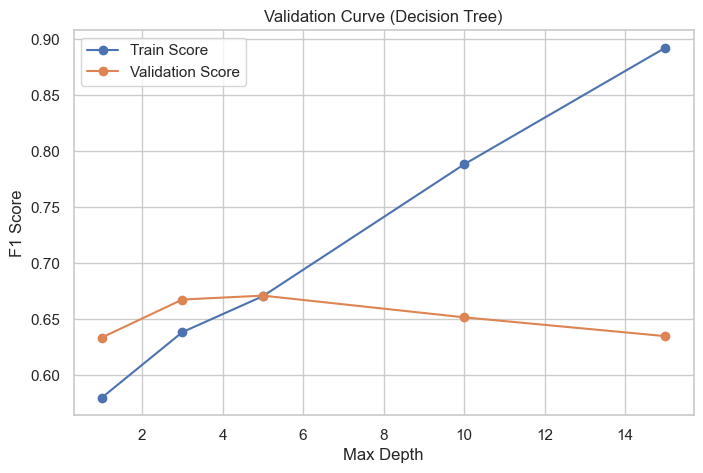

In [130]:
param_range = [1, 3, 5, 10, 15]

train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=tscv,
    scoring="f1_weighted"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))

plt.plot(param_range, train_mean, marker='o', label="Train Score")
plt.plot(param_range, val_mean, marker='o', label="Validation Score")

plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Validation Curve (Decision Tree)")
plt.legend()

plt.show()

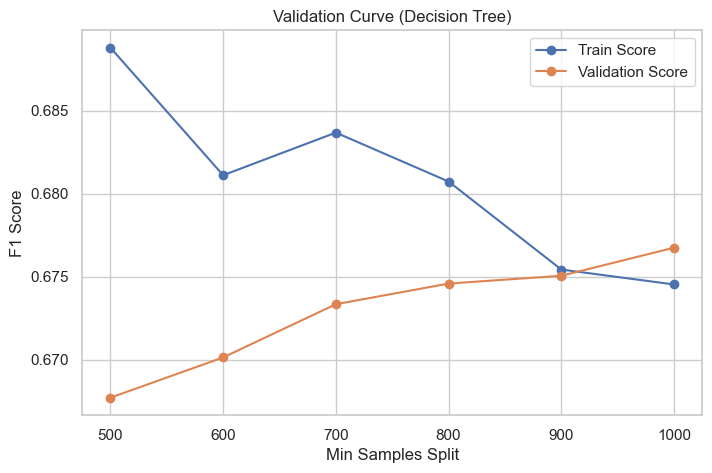

In [133]:
param_range = [500, 600, 700, 800, 900, 1000]

train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train,
    y_train,
    param_name="min_samples_split",
    param_range=param_range,
    cv=tscv,
    scoring="f1_weighted"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))

plt.plot(param_range, train_mean, marker='o', label="Train Score")
plt.plot(param_range, val_mean, marker='o', label="Validation Score")

plt.xlabel("Min Samples Split")
plt.ylabel("F1 Score")
plt.title("Validation Curve (Decision Tree)")
plt.legend()

plt.show()

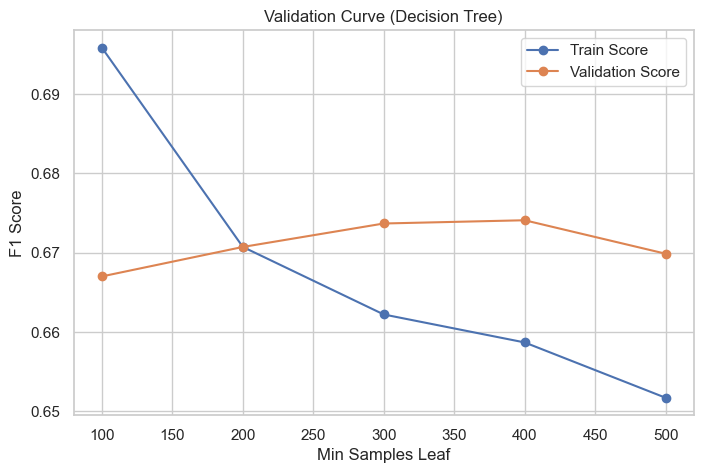

In [135]:
param_range = [100, 200, 300, 400, 500]

train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train,
    y_train,
    param_name="min_samples_leaf",
    param_range=param_range,
    cv=tscv,
    scoring="f1_weighted"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))

plt.plot(param_range, train_mean, marker='o', label="Train Score")
plt.plot(param_range, val_mean, marker='o', label="Validation Score")

plt.xlabel("Min Samples Leaf")
plt.ylabel("F1 Score")
plt.title("Validation Curve (Decision Tree)")
plt.legend()

plt.show()

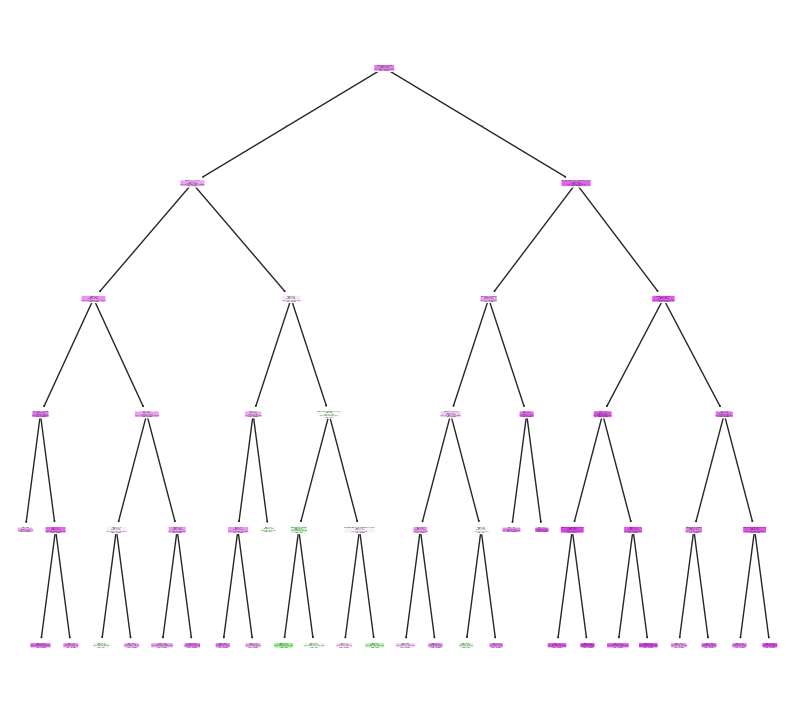

In [142]:
data_dtc = DecisionTreeClassifier(
    random_state=42, 
    min_samples_split=900,
    min_samples_leaf=200,
    max_depth=5) 

data_dtc = data_dtc.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc,
    filled=True,
    rounded=True,
    class_names=data_dtc.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

Decision Tree Accuracy: 0.725


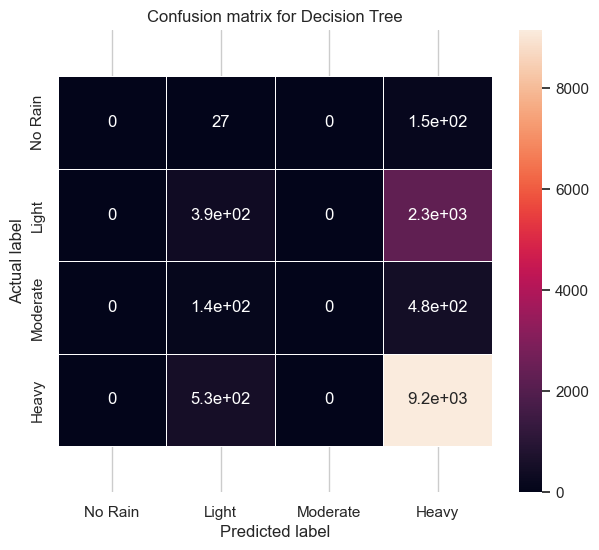

In [137]:
Y_pred = data_dtc.predict(X_test)
cm = confusion_matrix(y_test, Y_pred)
plt_confusion_matrix(cm, ["No Rain", "Light", "Moderate", "Heavy"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred),3))

In [138]:
data_dtc.fit(X_train, y_train)

train_score = data_dtc.score(X_train, y_train)
test_score = data_dtc.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.7422739194891094
Test score: 0.7251786528812528


In [139]:
labels = ["No Rain", "Light", "Moderate", "Heavy"]

print(classification_report(y_test, Y_pred, labels=labels))

              precision    recall  f1-score   support

     No Rain       0.76      0.94      0.84      9684
       Light       0.36      0.15      0.21      2674
    Moderate       0.00      0.00      0.00       620
       Heavy       0.00      0.00      0.00       176

    accuracy                           0.73     13154
   macro avg       0.28      0.27      0.26     13154
weighted avg       0.63      0.73      0.66     13154



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

The model’s accuracy decreased to 0.861 as it attempted to better predict minority classes. 

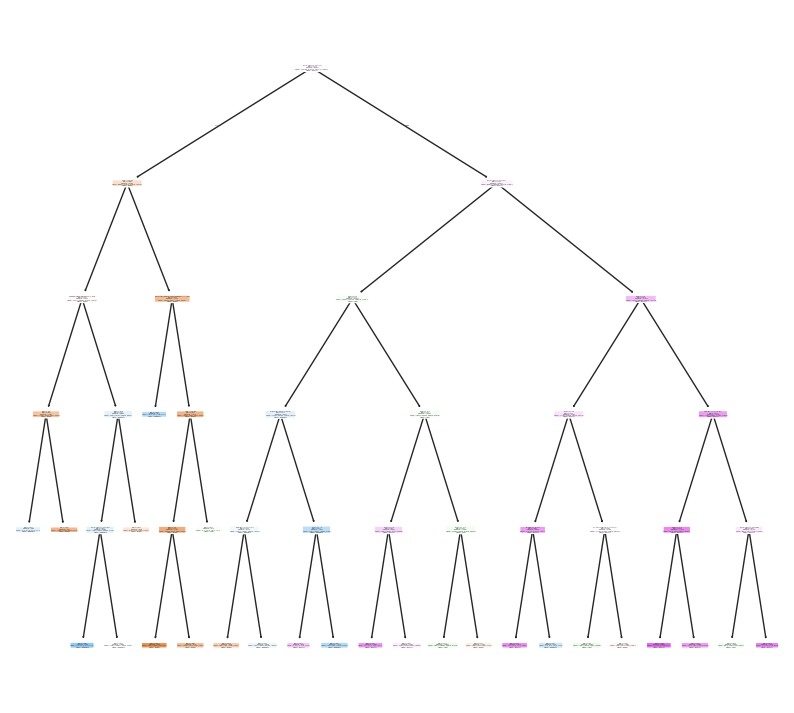

In [757]:
# balance classes
class_weight = {
    "No Rain": 0.6,
    "Light": 1.9,
    "Moderate": 8,
    "Heavy": 43
}

data_dtc_balanced = DecisionTreeClassifier(
    random_state=42, 
    min_samples_split=900,
    min_samples_leaf=200,
    max_depth=5,
    class_weight=class_weight) 

data_dtc_balanced = data_dtc_balanced.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc_balanced,
    filled=True,
    rounded=True,
    class_names=data_dtc_balanced.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

Decision Tree Accuracy: 0.466


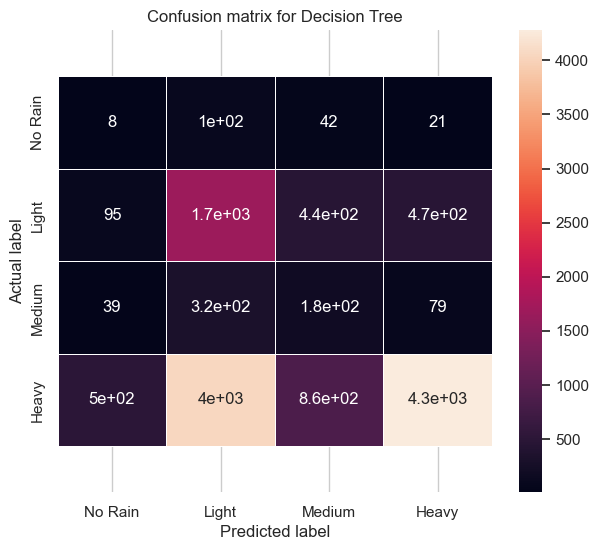

In [758]:
Y_pred_balanced = data_dtc_balanced.predict(X_test)
cm = confusion_matrix(y_test, Y_pred_balanced)
plt_confusion_matrix(cm, ["No Rain", "Light", "Medium", "Heavy"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred_balanced),3))

In [759]:
data_dtc_balanced.fit(X_train, y_train)

train_score = data_dtc_balanced.score(X_train, y_train)
test_score = data_dtc_balanced.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.4528262439654845
Test score: 0.465637828797324


In [760]:
labels = ["No Rain", "Light", "Moderate", "Heavy"]

print(classification_report(y_test, Y_pred_balanced, labels=labels))

              precision    recall  f1-score   support

     No Rain       0.88      0.44      0.59      9684
       Light       0.27      0.62      0.38      2674
    Moderate       0.12      0.29      0.17       620
       Heavy       0.01      0.05      0.02       176

    accuracy                           0.47     13154
   macro avg       0.32      0.35      0.29     13154
weighted avg       0.71      0.47      0.52     13154



Applying class weighting improved the model’s ability to detect minority classes such as heavy rainfall but overall performance remained limited due to the severe class imbalance. 

The model’s accuracy increased after class balancing. Performance improved drastically for "Heavy" and "Medium". Class weighting helped to reduce bias but it cannot fully compensate for insufficient data in rare categories.

In [91]:
y_shuffled = np.random.permutation(y)

scores = cross_val_score(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X,
    y_shuffled,
    cv=5,
    scoring="f1_weighted"
)

print(scores.mean())

0.49624475178961286


This checks whether the model is learning real patterns or just picking up unintended information from the data. By shuffling the labels, any true relationship between the features and the target is removed.

### Gradient Boosting

In [124]:
param_dist = {
    "max_iter": [40, 45, 50, 55, 60],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5],
    "max_leaf_nodes": [[1, 5, 10, 20, 30, 40, 50],
}

rand = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=tscv,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand.fit(X_train, y_train)

print("Best params:", rand.best_params_)
print("Best time-series CV score:", rand.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Best params: {'min_samples_leaf': 100, 'max_leaf_nodes': 15, 'max_iter': 150, 'learning_rate': 0.05, 'l2_regularization': 1.0}
Best time-series CV score: 0.6761122091657917


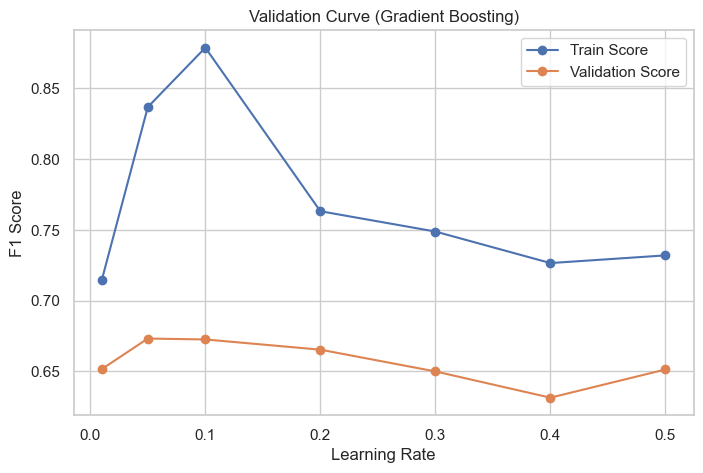

In [148]:
param_range = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

train_scores, val_scores = validation_curve(
    HistGradientBoostingClassifier(random_state=42),
    X_train,
    y_train,
    param_name="learning_rate",
    param_range=param_range,
    cv=tscv,
    scoring="f1_weighted"
)

# average scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# plot
plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, marker='o', label="Train Score")
plt.plot(param_range, val_mean, marker='o', label="Validation Score")

plt.xlabel("Learning Rate")
plt.ylabel("F1 Score")
plt.title("Validation Curve (Gradient Boosting)")
plt.legend()
plt.grid(True)

plt.show()

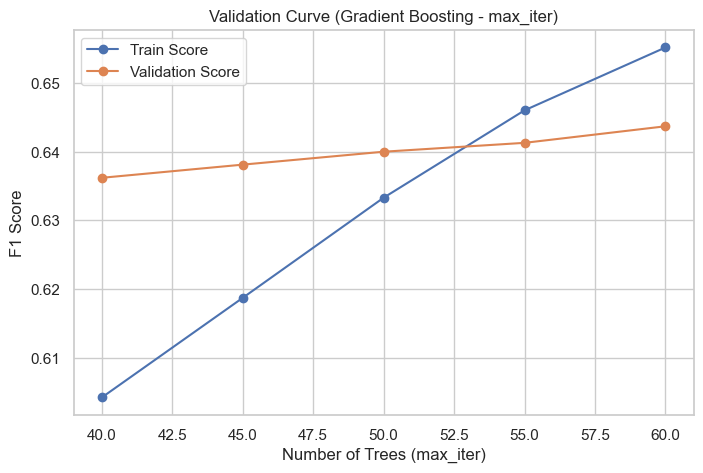

In [150]:
param_range = [40, 45, 50, 55, 60]

train_scores, val_scores = validation_curve(
    HistGradientBoostingClassifier(
        random_state=42,
        learning_rate=0.01 
    ),
    X_train,
    y_train,
    param_name="max_iter",
    param_range=param_range,
    cv=tscv,
    scoring="f1_weighted"
)

# mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# plot
plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, marker='o', label="Train Score")
plt.plot(param_range, val_mean, marker='o', label="Validation Score")

plt.xlabel("Number of Trees (max_iter)")
plt.ylabel("F1 Score")
plt.title("Validation Curve (Gradient Boosting - max_iter)")
plt.legend()
plt.grid(True)

plt.show()

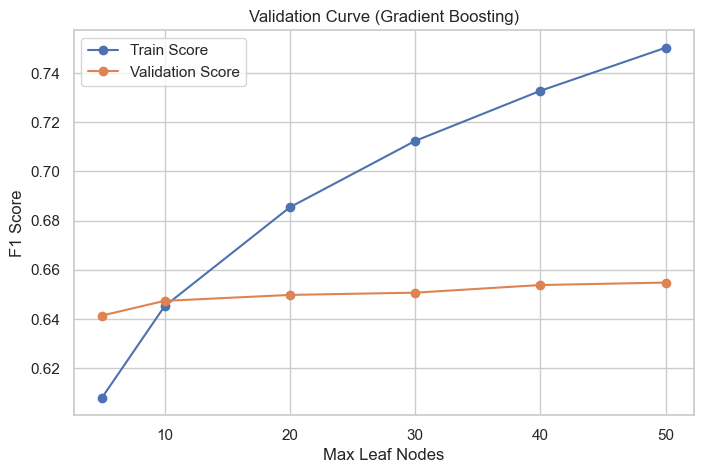

In [152]:
param_range = [1, 5, 10, 20, 30, 40, 50]

train_scores, val_scores = validation_curve(
    HistGradientBoostingClassifier(
        random_state=42,
        learning_rate=0.01  
    ),
    X_train,
    y_train,
    param_name="max_leaf_nodes",
    param_range=param_range,
    cv=tscv,
    scoring="f1_weighted"
)

# mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# plot
plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, marker='o', label="Train Score")
plt.plot(param_range, val_mean, marker='o', label="Validation Score")

plt.xlabel("Max Leaf Nodes")
plt.ylabel("F1 Score")
plt.title("Validation Curve (Gradient Boosting)")
plt.legend()
plt.grid(True)

plt.show()

In [761]:
from sklearn.utils.class_weight import compute_sample_weight

class_weight = {
    "No Rain": 0.6,
    "Light": 1.9,
    "Moderate": 8,
    "Heavy": 43
}

sample_weights = compute_sample_weight(
    class_weight=class_weight,
    y=y_train
)

gb_model = HistGradientBoostingClassifier(
    random_state=42,
    max_leaf_nodes=10,
    max_iter=55,
    learning_rate=0.01,
    l2_regularization=1.0
)

gb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", np.round(accuracy_score(y_test, y_pred_gb), 3))

labels = ["No Rain", "Light", "Moderate", "Heavy"]
print(classification_report(
    y_test,
    y_pred_gb,
    labels=labels,
    zero_division=0
))

Gradient Boosting Accuracy: 0.587
              precision    recall  f1-score   support

     No Rain       0.83      0.66      0.73      9684
       Light       0.27      0.44      0.34      2674
    Moderate       0.16      0.24      0.19       620
       Heavy       0.10      0.10      0.10       176

    accuracy                           0.59     13154
   macro avg       0.34      0.36      0.34     13154
weighted avg       0.68      0.59      0.62     13154



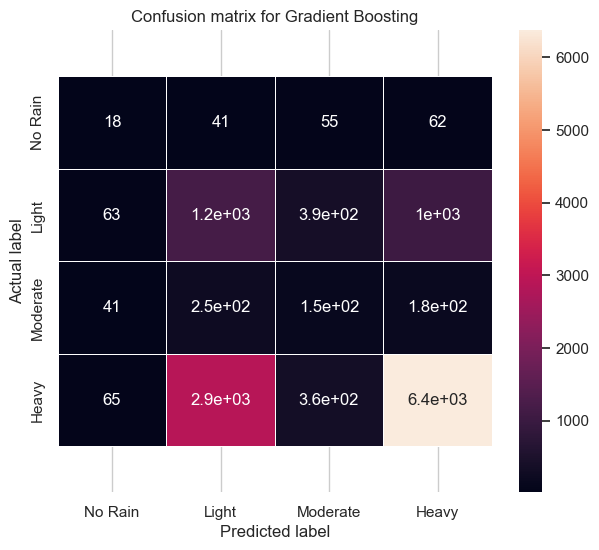

In [762]:
cm = confusion_matrix(y_test, y_pred_gb)
plt_confusion_matrix(cm, ["No Rain", "Light", "Moderate", "Heavy"], "Gradient Boosting") 

In [696]:
gb_model.fit(X_train, y_train)

train_score = gb_model.score(X_train, y_train)
test_score = gb_model.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.7315543391492758
Test score: 0.7362019157670671


### Gradient Boosting Prediction

In [638]:
# predict on forecast data
forecast_preds = gb_model.predict(X_forecast)

# create results
forecast_results = forecast_data[["Datetime"]].copy()

# because y is shifted -24, the prediction is for 24 hours later
forecast_results["Target_Datetime"] = forecast_results["Datetime"] + pd.Timedelta(hours=24)

forecast_results["Actual_Rainfall_Level"] = y_forecast_actual.values
forecast_results["Predicted_Rainfall_Level"] = forecast_preds

In [639]:
rain_order = {
    "No Rain": 0,
    "Light": 1,
    "Medium": 2,
    "Moderate": 2,
    "Heavy": 3,
    "Extreme": 4
}

forecast_results["Predicted_Rainfall_Index"] = forecast_results["Predicted_Rainfall_Level"].map(rain_order)
forecast_results["Actual_Rainfall_Index"] = forecast_results["Actual_Rainfall_Level"].map(rain_order)

forecast_results["Target_Date"] = forecast_results["Target_Datetime"].dt.date

daily_forecast = (
    forecast_results
    .groupby("Target_Date")
    .agg({
        "Predicted_Rainfall_Index": "max",
        "Actual_Rainfall_Index": "max"
    })
    .reset_index()
)

In [640]:
reverse_map = {
    0: "No Rain",
    1: "Light",
    2: "Moderate",
    3: "Heavy",
    4: "Extreme"
}

daily_forecast["Predicted_Rainfall_Level"] = daily_forecast["Predicted_Rainfall_Index"].map(reverse_map)
daily_forecast["Actual_Rainfall_Level"] = daily_forecast["Actual_Rainfall_Index"].map(reverse_map)

daily_forecast.head()

,Target_Date,Predicted_Rainfall_Index,Actual_Rainfall_Index,Predicted_Rainfall_Level,Actual_Rainfall_Level
0,2022-02-02,3,1,Heavy,Light
1,2022-02-03,1,1,Light,Light
2,2022-02-04,1,1,Light,Light
3,2022-02-05,0,0,No Rain,No Rain
4,2022-02-06,0,0,No Rain,No Rain


In [641]:
print("Daily forecast accuracy:")
print(accuracy_score(
    daily_forecast["Actual_Rainfall_Level"],
    daily_forecast["Predicted_Rainfall_Level"]
))

Daily forecast accuracy:
0.6285714285714286


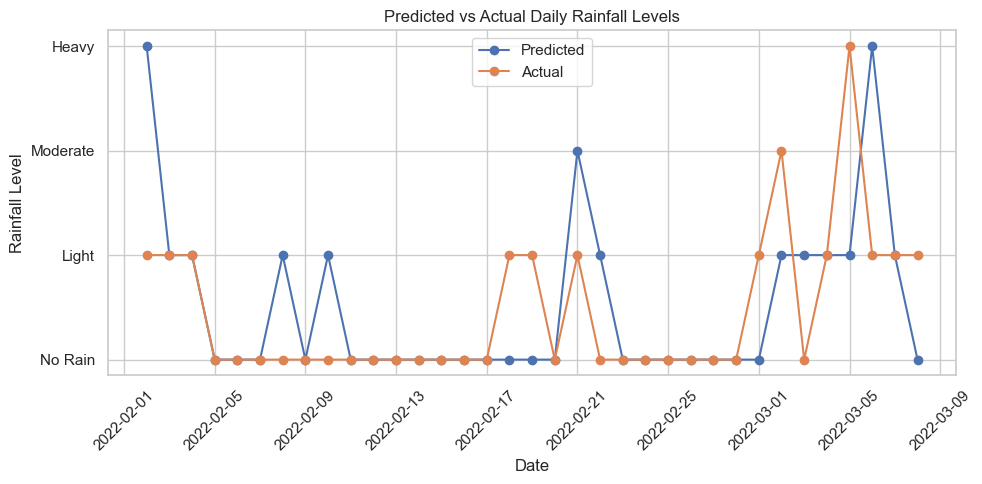

In [642]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_forecast["Target_Date"],
    daily_forecast["Predicted_Rainfall_Index"],
    marker="o",
    label="Predicted"
)

plt.plot(
    daily_forecast["Target_Date"],
    daily_forecast["Actual_Rainfall_Index"],
    marker="o",
    label="Actual"
)

plt.yticks(
    [0, 1, 2, 3],
    ["No Rain", "Light", "Moderate", "Heavy"]
)

plt.xlabel("Date")
plt.ylabel("Rainfall Level")
plt.title("Predicted vs Actual Daily Rainfall Levels")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

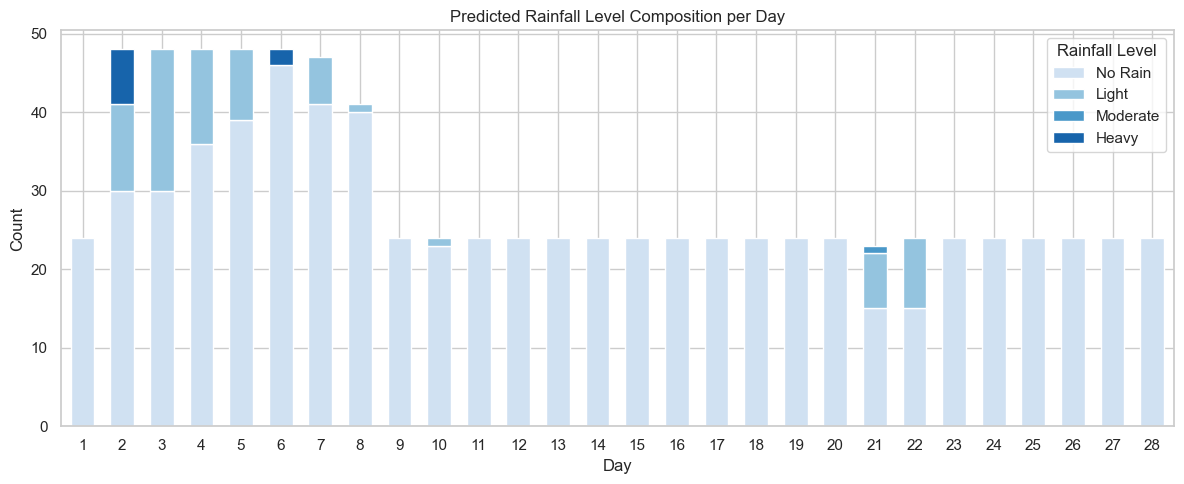

In [643]:
sns.set_theme(style="whitegrid")

order = ["No Rain", "Light", "Moderate", "Heavy"]

# make sure Target_Date exists
forecast_results["Target_Datetime"] = forecast_results["Datetime"] + pd.Timedelta(hours=24)
forecast_results["Target_Date"] = forecast_results["Target_Datetime"].dt.date
forecast_results["Day"] = forecast_results["Target_Datetime"].dt.day

# crosstab hourly predictions per day
table_pred = pd.crosstab(
    forecast_results["Day"],
    forecast_results["Predicted_Rainfall_Level"]
).reindex(columns=order, fill_value=0)

colors = sns.color_palette("Blues", n_colors=len(order))

table_pred.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(12, 5),
    width=0.6
)

plt.title("Predicted Rainfall Level Composition per Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Rainfall Level")
plt.tight_layout()
plt.show()

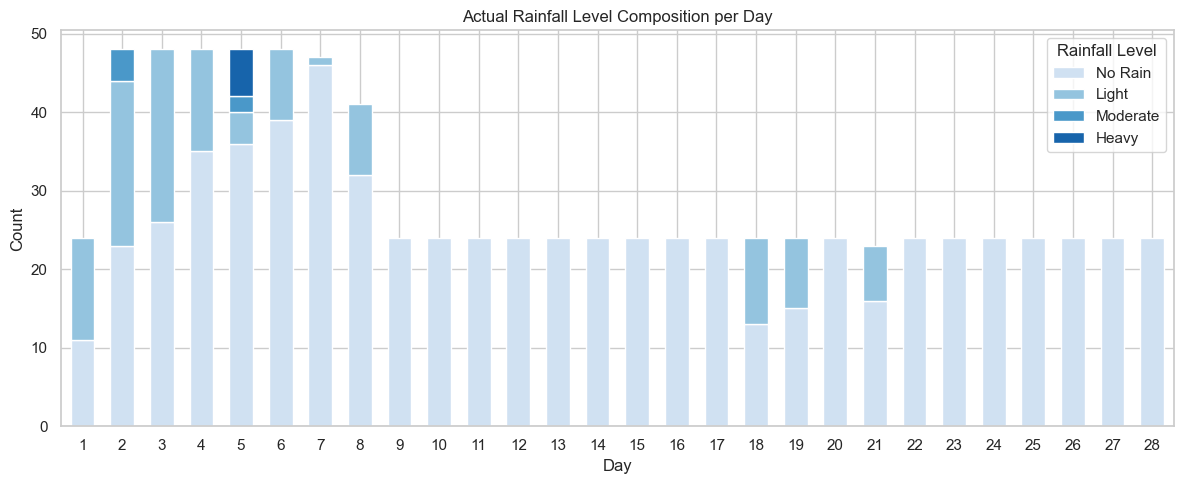

In [644]:
table_actual = pd.crosstab(
    forecast_results["Day"],
    forecast_results["Actual_Rainfall_Level"]
).reindex(columns=order, fill_value=0)

table_actual.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(12, 5),
    width=0.6
)

plt.title("Actual Rainfall Level Composition per Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Rainfall Level")
plt.tight_layout()
plt.show()

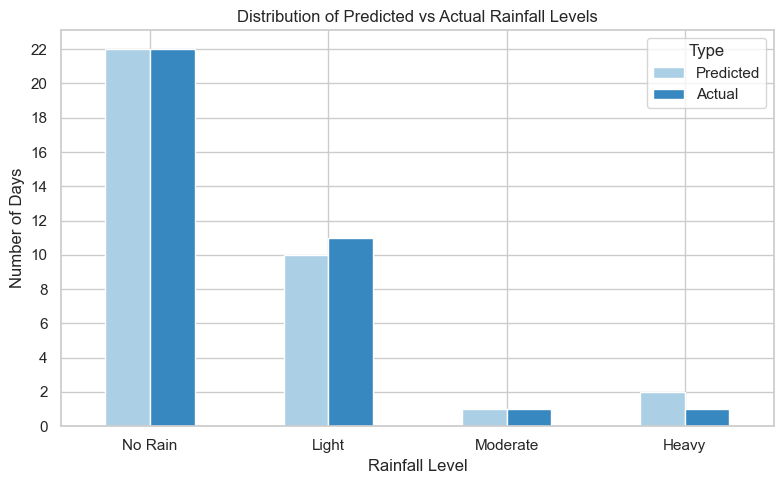

In [645]:
sns.set_theme(style="whitegrid")

order = ["No Rain", "Light", "Moderate", "Heavy"]

# counts for predicted and actual
pred_counts = daily_forecast["Predicted_Rainfall_Level"].value_counts().reindex(order, fill_value=0)
actual_counts = daily_forecast["Actual_Rainfall_Level"].value_counts().reindex(order, fill_value=0)

# combine into one dataframe
compare_counts = pd.DataFrame({
    "Predicted": pred_counts,
    "Actual": actual_counts
})

# plot side-by-side bars
colors = sns.color_palette("Blues", n_colors=2)

compare_counts.plot(
    kind="bar",
    figsize=(8, 5),
    color=colors
)

plt.title("Distribution of Predicted vs Actual Rainfall Levels")
plt.xlabel("Rainfall Level")
plt.ylabel("Number of Days")
plt.xticks(rotation=0)
plt.yticks(np.arange(0, compare_counts.max().max() + 2, 2))
plt.legend(title="Type")
plt.tight_layout()
plt.show()

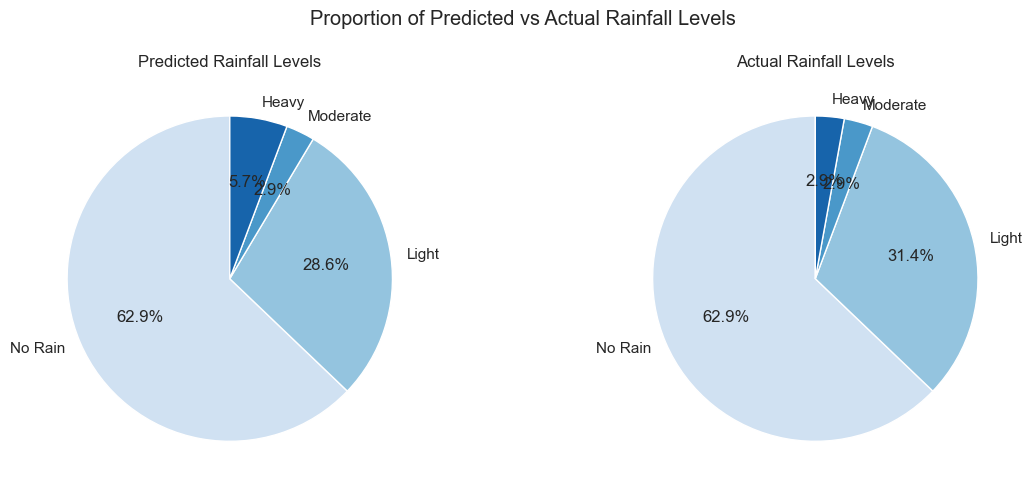

In [649]:
order = ["No Rain", "Light", "Moderate", "Heavy"]

# predicted and actual counts
pred_counts = (
    daily_forecast["Predicted_Rainfall_Level"]
    .value_counts()
    .reindex(order, fill_value=0)
)

actual_counts = (
    daily_forecast["Actual_Rainfall_Level"]
    .value_counts()
    .reindex(order, fill_value=0)
)

# blue gradient
colours = sns.color_palette("Blues", n_colors=len(order))

# side-by-side pie charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pred_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=colours,
    startangle=90,
    ax=axes[0]
)
axes[0].set_title("Predicted Rainfall Levels")
axes[0].set_ylabel("")

actual_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=colours,
    startangle=90,
    ax=axes[1]
)
axes[1].set_title("Actual Rainfall Levels")
axes[1].set_ylabel("")

plt.suptitle("Proportion of Predicted vs Actual Rainfall Levels")
plt.tight_layout()
plt.show()